# Stellar-Age BNN: read → normalize → train

End-to-end pipeline for the **asteroseismic** dataset produced by `dataset_analysis.ipynb`
(`data_filt_*.csv`):

1. **Read** the single derived catalog and map its column names to the convention the
   prep/train code expects, then split into train/test (the file is not pre-split).
2. **Normalize** — clean labels, derive `[C/N]`, and standardize features using
   **train-only** statistics (no leakage). Reuses the helpers in `prepare_dataset.py`.
3. **Train** the robust BNN with input-uncertainty propagation, then evaluate on the
   held-out split. Reuses the model + training code in `train_bnn.py`.

Designed to run on Gadi (or anywhere the repo + dataset live).

## 1. Setup

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

# Locate the repo hol

In [2]:

CANDIDATES = [
    '~/scr_mk27/bingo-modern',
    '~/code/bingo-modern',
    '.',
]
repo = next((p for p in map(os.path.expanduser, CANDIDATES)
             if os.path.isfile(os.path.join(p, 'prepare_dataset.py'))), None)
if repo is None:
    raise FileNotFoundError('Could not find prepare_dataset.py. Add its dir to CANDIDATES.')
repo = os.path.abspath(repo)
os.chdir(repo)
sys.path.insert(0, repo)
print('repo:', repo)

import prepare_dataset as prep
from train_bnn import (
    set_seed,
    BayesianNeuralNetwork,
    train_smooth_bnn,
    get_targeted_posterior_samples,
    analyze_targeted_results,
    device,
)
print(f'Using device: {device}')

repo: /home/100/mj8805/scr_mk27/bingo-modern
Using device: cuda
Using device: cuda


## 2. Configuration

In [3]:
# Dataset produced by dataset_analysis.ipynb (point this at the split you want).
DATASET = './data_filt_AGB.csv'
OUTPUT_DIR = Path('./BNN_targeted_output_AGB')
OUTPUT_DIR.mkdir(exist_ok=True)

TEST_FRAC = 0.2          # held-out fraction (the catalog is a single, unsplit file)
SEED = 42
NUM_ITERATIONS = 8000
BATCH_SIZE = 512
INITIAL_LR = 0.005

# Map the derived (lowercase) schema -> the convention prepare_dataset/train_bnn expect:
# ID = APOGEE_ID, target = logAge/logAgeErr, features FOO with error FOO_ERR.
RENAME = {
    'sdss_id': prep.ID_COL,
    'log_age': prep.TARGET, 'e_log_age': prep.TARGET_ERR,
    'teff': 'TEFF',   'e_teff': 'TEFF_ERR',
    'logg': 'LOGG',   'e_logg': 'LOGG_ERR',
    'fe_h': 'FE_H',   'e_fe_h': 'FE_H_ERR',
    'mg_fe': 'MG_FE', 'e_mg_fe': 'MG_FE_ERR',
    'n_fe': 'N_FE',   'e_n_fe': 'N_FE_ERR',
    'c_fe': 'C_FE',   'e_c_fe': 'C_FE_ERR',
}

# Features the model sees (base columns + the engineered [C/N]).
FEATURES = prep.BASE_FEATURES + ['C_N']
FEATURE_COLS = [f'{f}_NORM' for f in FEATURES]
ERROR_COLS = [f'{f}_ERR_NORM' for f in FEATURES]
FEATURES

['LOGG', 'TEFF', 'MG_FE', 'FE_H', 'C_FE', 'N_FE', 'C_N']

## 3. Read & map the dataset

Rename to the expected schema, synthesize `age = 10**logAge` (needed by
`clean_labels`' age cap), and split into train/test with a fixed seed.

In [4]:
df = pd.read_csv(DATASET)
# data_filt was written with the default index -> drop the stray 'Unnamed: 0' column.
df = df.loc[:, ~df.columns.str.startswith('Unnamed')]
df = df.rename(columns=RENAME)
df['age'] = 10.0 ** df[prep.TARGET]   # Gyr, for the unphysical-age cap in clean_labels
print(f'Loaded {len(df)} stars, {df.shape[1]} columns')

# Reproducible train/test split (single-file catalog -> split here).
rng = np.random.default_rng(SEED)
idx = rng.permutation(len(df))
n_test = int(round(TEST_FRAC * len(df)))
test_raw = df.iloc[idx[:n_test]].reset_index(drop=True)
train_raw = df.iloc[idx[n_test:]].reset_index(drop=True)
print(f'Train: {len(train_raw)}  |  Test: {len(test_raw)}')
train_raw.head()

Loaded 3442 stars, 16 columns
Train: 2754  |  Test: 688


,APOGEE_ID,logAge,logAgeErr,TEFF,TEFF_ERR,LOGG,LOGG_ERR,FE_H,FE_H_ERR,MG_FE,MG_FE_ERR,N_FE,N_FE_ERR,C_FE,C_FE_ERR,age
0,66661701,0.891838,0.084064,4308.664,4.322,2.622,0.012,0.266,0.003,0.006,0.005,0.243,0.012,0.081,0.005,7.795394
1,67453395,0.989601,0.133668,4314.152,1.588,2.301,0.007,-0.231,0.001,0.104,0.002,0.130,0.005,0.048,0.003,9.763401
2,67479918,0.921910,0.053073,4732.678,10.929,2.765,0.023,-0.528,0.003,0.174,0.007,0.008,0.028,0.097,0.018,8.354304
3,67726872,0.862120,0.040637,4888.066,6.308,3.250,0.009,-0.169,0.001,0.046,0.003,0.146,0.014,-0.005,0.009,7.279804
4,67127874,0.668180,0.103549,4635.032,3.890,2.582,0.009,-0.301,0.001,0.047,0.003,0.208,0.009,-0.044,0.005,4.657796


## 4. Normalize

Clean labels/errors, derive `[C/N]`, remove any train/test ID leakage, then standardize
with **train-only** statistics.

In [5]:
train, train_rep = prep.clean_labels(train_raw, 'train')
test, test_rep = prep.clean_labels(test_raw, 'test')

# Guard against the same star landing in both splits (shouldn't happen with a permutation
# split, but clean_labels can drop rows, so verify rather than assume).
overlap = set(train[prep.ID_COL]) & set(test[prep.ID_COL])
if overlap:
    print(f'Removing {len(overlap)} leaked IDs from the test set')
    test = test[~test[prep.ID_COL].isin(overlap)].reset_index(drop=True)

# Engineer [C/N] (+ propagated error)
train = prep.derive_features(train)
test = prep.derive_features(test)

# Fit normalization on TRAIN ONLY, then apply to both splits
stats = prep.fit_norm_stats(train, FEATURES)
train = prep.apply_norm(train, FEATURES, stats)
test = prep.apply_norm(test, FEATURES, stats)

# Inverse-frequency sample weights to fight age imbalance (train only)
train, edges, _ = prep.add_sample_weights(train, prep.N_AGE_BINS, prep.WEIGHT_CLIP)

print(f'\nTrain: {len(train)} stars | Test: {len(test)} stars')
train[FEATURE_COLS].describe()

[train] cleaning: 2754 -> 2664 rows  {'dropped_nan': 90, 'capped_unphysical_age': 20, 'cap_age_gyr': 14.0, 'dropped_bad_errors': 0}
[test] cleaning: 688 -> 668 rows  {'dropped_nan': 20, 'capped_unphysical_age': 6, 'cap_age_gyr': 14.0, 'dropped_bad_errors': 0}

Train: 2664 stars | Test: 668 stars


,LOGG_NORM,TEFF_NORM,MG_FE_NORM,FE_H_NORM,C_FE_NORM,N_FE_NORM,C_N_NORM
count,2.664000e+03,2.664000e+03,2.664000e+03,2.664000e+03,2.664000e+03,2.664000e+03,2.664000e+03
mean,-8.575056e-16,2.774057e-15,7.068087e-17,-3.334003e-17,-6.668006e-18,-1.266921e-16,-1.160233e-16
std,1.000188e+00,1.000188e+00,1.000188e+00,1.000188e+00,1.000188e+00,1.000188e+00,1.000188e+00
min,-3.295021e+00,-3.018833e+00,-1.684400e+00,-6.227782e+00,-4.599204e+00,-6.256122e+00,-4.478064e+00
25%,-7.462861e-01,-7.313373e-01,-6.737333e-01,-6.494841e-01,-6.930320e-01,-5.858715e-01,-6.768887e-01
50%,-1.014255e-01,-1.007431e-01,-3.324693e-01,5.642802e-02,-3.025197e-02,5.985098e-02,-5.463227e-02
75%,8.030543e-01,7.097081e-01,2.713055e-01,7.145716e-01,7.171383e-01,6.147687e-01,6.284971e-01
max,2.813009e+00,3.728246e+00,3.408309e+00,2.124273e+00,3.777208e+00,3.803024e+00,4.253817e+00


In [6]:
prep.validate(train, test, FEATURES, edges)


VALIDATION REPORT

  TRAIN (logAge histogram, n=2664):
    [-0.21,-0.10)     9 
    [-0.10,+0.01)    17 #
    [+0.01,+0.13)    29 ##
    [+0.13,+0.24)    58 ####
    [+0.24,+0.35)   107 ########
    [+0.35,+0.47)   189 ##############
    [+0.47,+0.58)   280 #####################
    [+0.58,+0.69)   357 ###########################
    [+0.69,+0.81)   463 ###################################
    [+0.81,+0.92)   516 ########################################
    [+0.92,+1.03)   497 ######################################
    [+1.03,+1.15)   142 ###########

  TEST (logAge histogram, n=668):
    [-0.21,-0.10)     0 
    [-0.10,+0.01)     3 
    [+0.01,+0.13)     2 
    [+0.13,+0.24)    12 ###
    [+0.24,+0.35)    25 #######
    [+0.35,+0.47)    46 ############
    [+0.47,+0.58)    69 ###################
    [+0.58,+0.69)    97 ###########################
    [+0.69,+0.81)   117 ################################
    [+0.81,+0.92)   142 ########################################
    [+0.92,+1.03) 

## 5. Build tensors

In [7]:
def to_arrays(d):
    X = d[FEATURE_COLS].values.astype(np.float32)
    X_err = d[ERROR_COLS].values.astype(np.float32)
    y = d[prep.TARGET].values.astype(np.float32)
    y_err = d[prep.TARGET_ERR].values.astype(np.float32)
    # Inverse-frequency age weights (mean 1). Test split has no weights -> ones.
    w = (d['train_weight'].values if 'train_weight' in d.columns
         else np.ones(len(d))).astype(np.float32)
    return X, X_err, y, y_err, w


X_train, X_err_train, y_train, y_err_train, w_train = to_arrays(train)
X_test, X_err_test, y_test, y_err_test, w_test = to_arrays(test)

print(f'Features: {X_train.shape[1]}  ({FEATURE_COLS})')
print(f'logAge range: [{y_train.min():.3f}, {y_train.max():.3f}]')
print(f'train_weight: mean={w_train.mean():.3f}, min={w_train.min():.3f}, max={w_train.max():.3f}')

X_train_t = torch.FloatTensor(X_train).to(device)
X_err_train_t = torch.FloatTensor(X_err_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
y_err_train_t = torch.FloatTensor(y_err_train).to(device)

# Per-star likelihood weight. The bare inverse-frequency weight (mean 1)
# rebalances the age distribution. Multiplying by N_total / batch_size also
# applies the minibatch-correct ELBO scaling so the data term is not
# over-regularized by the once-per-step KL (reduces shrinkage to the mean).
# Set USE_MINIBATCH_KL_SCALE = False to rebalance only.
USE_MINIBATCH_KL_SCALE = True
kl_scale = (len(X_train) / BATCH_SIZE) if USE_MINIBATCH_KL_SCALE else 1.0
w_train_t = torch.FloatTensor(w_train * kl_scale).to(device)

Features: 7  (['LOGG_NORM', 'TEFF_NORM', 'MG_FE_NORM', 'FE_H_NORM', 'C_FE_NORM', 'N_FE_NORM', 'C_N_NORM'])
logAge range: [-0.212, 1.146]


## 6. Train the network

In [ ]:
set_seed(SEED)

y_std = float(np.std(y_train))
print(f'Empirical logAge stats - mean: {y_mean:.3f}, std: {y_std:.3f}')

model = BayesianNeuralNetwork(
    input_dim=X_train.shape[1],
    hidden_dim=32,
    use_skip_connections=True,
    use_empirical_output_bias=False,  # mean-zero bias prior: less shrinkage to y_mean
    use_leaky_relu=True,
    y_mean=y_mean,
    y_std=y_std,
)
model.to(device)

guide, losses = train_smooth_bnn(
    model,
    X_train_t, X_err_train_t,
    y_train_t, y_err_train_t,
    num_iterations=NUM_ITERATIONS,
    initial_lr=INITIAL_LR,
    batch_size=BATCH_SIZE,
    warmup_epochs=20,
    seed=SEED,
    w_train=w_train_t,  # inverse-frequency age weights (+ optional KL scaling)
)

Empirical logAge stats - mean: 0.724, std: 0.243

Training Smooth Bayesian Neural Network
With Learning Rate Warmup and Better Stability
Using random seed: 42
Parameter store cleared for clean training start
Training for 1333 epochs with 6 batches per epoch...
Total iterations: 8000
Initial learning rate: 0.005
Batch size: 512 (covers 19.2% of data per batch)


Training:   8%|████▌                                                        | 100/1333 [00:32<06:16,  3.27it/s, loss=3606.62, smooth=4029.59, lr=0.00500]

Epoch 100/1333: Loss = 3606.6208 ± 79.7455, Smoothed = 4029.5886


Training:  14%|████████▏                                                    | 180/1333 [00:57<06:09,  3.12it/s, loss=2543.29, smooth=2809.74, lr=0.00500]


KeyboardInterrupt: 

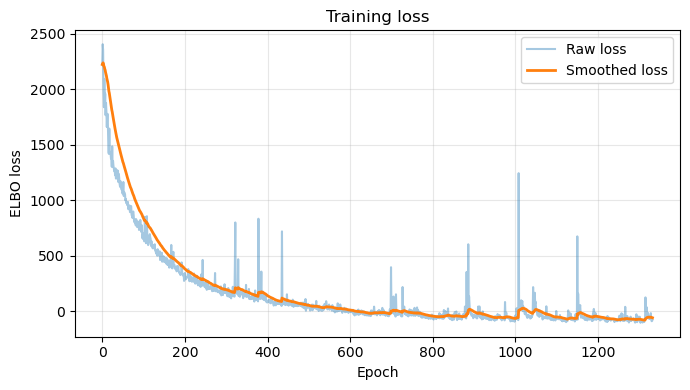

In [ ]:
import pyro

pyro.get_param_store().save(str(OUTPUT_DIR / 'targeted_bnn_params.pth'))

plt.figure(figsize=(7, 4))
plt.plot(losses, alpha=0.4, label='Raw loss')
smoothed = []
for i, loss in enumerate(losses):
    smoothed.append(loss if i == 0 else 0.95 * smoothed[-1] + 0.05 * loss)
plt.plot(smoothed, lw=2, label='Smoothed loss')
plt.xlabel('Epoch')
plt.ylabel('ELBO loss')
plt.title('Training loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Evaluate on the held-out split

In [ ]:
X_test_t = torch.FloatTensor(X_test).to(device)
X_err_test_t = torch.FloatTensor(X_err_test).to(device)
y_err_test_t = torch.FloatTensor(y_err_test).to(device)

total_samples, mean_predictions, model_unc, intrinsic_scatter = get_targeted_posterior_samples(
    model, guide, X_test_t, X_err_test_t, y_err_test_t, num_samples=5000
)

summary = analyze_targeted_results(
    total_samples, mean_predictions, model_unc, intrinsic_scatter, y_err_test, y_test
)
summary.to_csv(OUTPUT_DIR / 'targeted_prediction_summary.csv', index=False)
summary.head()


Generating 5000 posterior samples from targeted model...
Combining uncertainty components...
Mean intrinsic scatter: 0.0848 ± 0.0063 dex
Mean model uncertainty: 0.0674 dex
Mean observational uncertainty: 0.0656 dex

HIGH AGE STAR PERFORMANCE (logAge > 1):
Number of high age stars: 61
High age MAE: 0.1076 dex
High age RMS: 0.1309 dex
High age correlation: 0.081
High age fraction within 1σ: 82.0%
High age prediction range: [0.5722, 1.0239]
High age prediction mean: 0.9484

TARGETED MODEL RESULTS:
Mean observational uncertainty: 0.0656 dex
Mean model uncertainty: 0.0674 dex
Intrinsic scatter: 0.0848 dex
Mean total uncertainty: 0.1433 dex

Overall Performance Metrics:
Mean Absolute Error: 0.0861 dex
RMS Error: 0.1185 dex
Correlation: 0.859
Fraction within 1σ: 82.5%
Fraction within 2σ: 97.8%


,observational_uncertainty,model_uncertainty,intrinsic_scatter,total_predictive_uncertainty,pred_median,pred_mean_only,true_age,theoretical_total,residual,normalized_residual
0,0.084121,0.066856,0.084757,0.140814,0.600969,0.597079,0.582117,0.136857,-0.018852,-0.133878
1,0.050099,0.067650,0.084757,0.138900,0.964091,0.962528,0.991289,0.119457,0.027198,0.195809
2,0.045103,0.066920,0.084757,0.122984,0.617833,0.621316,0.706665,0.117031,0.088832,0.722306
3,0.065896,0.067780,0.084757,0.154816,0.328604,0.328010,0.380324,0.126965,0.051721,0.334078
4,0.051124,0.067690,0.084757,0.138870,0.965869,0.964085,0.982465,0.119914,0.016596,0.119509


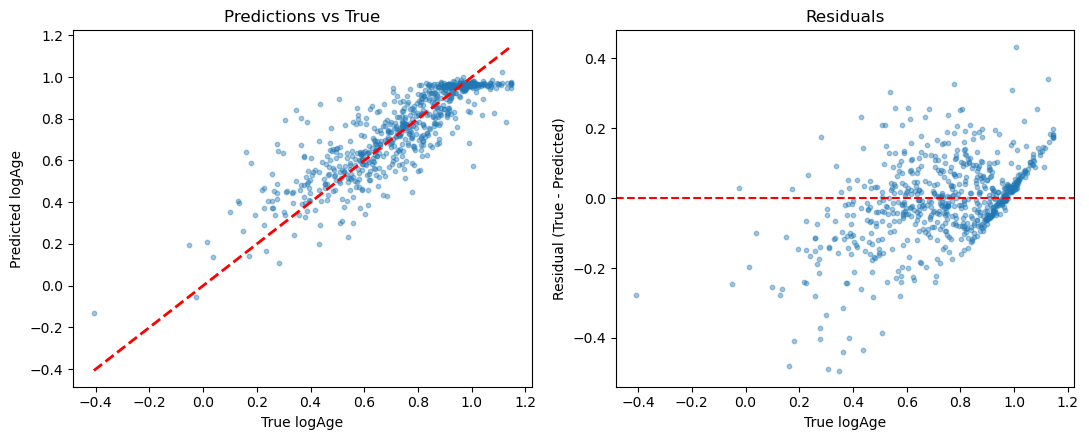

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].scatter(y_test, summary['pred_median'], alpha=0.4, s=10)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, 'r--', lw=2)
axes[0].set_xlabel('True logAge')
axes[0].set_ylabel('Predicted logAge')
axes[0].set_title('Predictions vs True')

axes[1].scatter(y_test, summary['residual'], alpha=0.4, s=10)
axes[1].axhline(0, color='r', ls='--')
axes[1].set_xlabel('True logAge')
axes[1].set_ylabel('Residual (True - Predicted)')
axes[1].set_title('Residuals')

plt.tight_layout()
plt.show()